# Training the model

## Importing dependencies

In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import tiktoken

import optax

In [2]:
from helper import NanoJAX, load_and_preprocess_data, generate_text

## Loading data and model

In [3]:
maxlen=128
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
text_dl, batches_per_epoch = load_and_preprocess_data(
    file_path='TinyStories-1000.txt',
    batch_size=32,
    maxlen=128,
    max_stories=1000,
    shuffle=False,
    seed=42
)

Loading data from TinyStories-1000.txt (max 1,000 stories)
Loaded 1,000 stories
Estimated batches per epoch: 31
Created DataLoader with batch_size=32, maxlen=128


In [5]:
model = NanoJAX()

## Defining the loss function

In [6]:
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs) # The output of the model is the logits
    # If the value is high, the model is confident that the prediction should select it as the next word
    # If the value is low, the model is confident that the prediction is incorrect
    loss = optax.softmax_cross_entropy_with_integer_labels( # We convert the targets into probabilities
        logits, targets
    ).mean() # We take the mean of the loss so we can use the single loss function to back propogate
    return loss, logits

## Defining the training steps

In [7]:
num_epochs=3
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup, before the network is warmed up, it starts off at a random state that can cause troble when training
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 93
Warmup steps: 9


In [8]:
lr_schedule = optax.warmup_cosine_decay_schedule( # We define the warmup rate here
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5 # Varies the learning rate over time
)

## Defining the optimiser 

In [9]:
# The optimiser controls how the neural network learns
optimiser = nnx.ModelAndOptimizer(
    model,
    optax.adamw(
        learning_rate=lr_schedule,
        weight_decay=0.01
    )
)

In [10]:
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

## JIT compile the training step

The training step here is defined with the nnx.jit decorator which caches the compiled code and allows us to get a faster training loop, so the compiler doesn't have to recompile for every iteration

In [11]:
@nnx.jit
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1]) # We update the metrics with the loss and logits
    optimizer.update(grads)

## Running the training loop

In [12]:
metrics_history = {'train_loss': []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch( # We convert our inputs and targets into jax arrays 
            jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimiser, metrics, (input_batch, target_batch))

        if (step + 1) % 2 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value) # We append the metrics to the metrics history to track how well the model is doing
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1

..
Epoch: 1, Step 2, Loss: 10.8881, LR: 3.33e-05
..
Epoch: 1, Step 4, Loss: 10.8503, LR: 1.00e-04
..
Epoch: 1, Step 6, Loss: 10.7516, LR: 1.67e-04
..
Epoch: 1, Step 8, Loss: 10.6021, LR: 2.33e-04
..
Epoch: 1, Step 10, Loss: 10.3302, LR: 3.00e-04
..
Epoch: 1, Step 12, Loss: 9.9892, LR: 3.00e-04
..
Epoch: 1, Step 14, Loss: 9.6364, LR: 2.98e-04
..
Epoch: 1, Step 16, Loss: 9.3029, LR: 2.96e-04
..
Epoch: 1, Step 18, Loss: 8.9978, LR: 2.94e-04
..
Epoch: 1, Step 20, Loss: 8.7415, LR: 2.90e-04
..
Epoch: 1, Step 22, Loss: 8.5462, LR: 2.86e-04
..
Epoch: 1, Step 24, Loss: 8.4231, LR: 2.81e-04
..
Epoch: 1, Step 26, Loss: 8.0863, LR: 2.75e-04
..
Epoch: 1, Step 28, Loss: 7.8025, LR: 2.68e-04
..
Epoch: 1, Step 30, Loss: 7.6615, LR: 2.61e-04
...
Epoch: 2, Step 2, Loss: 7.3864, LR: 3.33e-05
..
Epoch: 2, Step 4, Loss: 7.2806, LR: 1.00e-04
..
Epoch: 2, Step 6, Loss: 7.0863, LR: 1.67e-04
..
Epoch: 2, Step 8, Loss: 6.9986, LR: 2.33e-04
..
Epoch: 2, Step 10, Loss: 6.8182, LR: 3.00e-04
..
Epoch: 2, Step 12, 

## Viusalising the model performance 

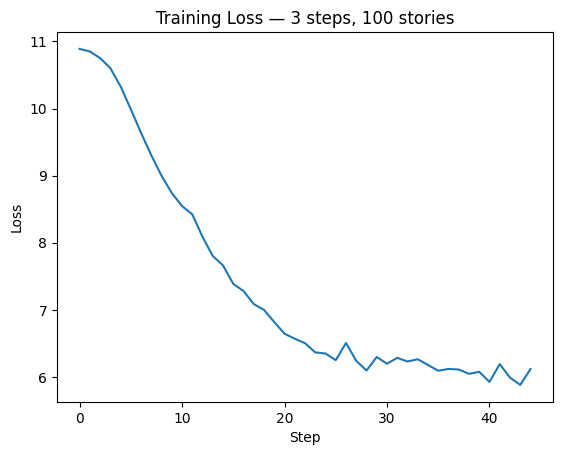

In [13]:
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss — 3 steps, 100 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Saving the model checkpoints

In [14]:
from pathlib import Path
import orbax

checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as c:\Users\danie\Desktop\Projects\JAX-Nano-Model\small_checkpoint.orbax
